# N-BEATS Prediction Pipeline

This notebook follows the same benchmark format as the LSTM/BiLSTM notebooks, but replaces the recurrent model layer with ServiceNow Research N-BEATS.

PDF concept summary:

- N-BEATS is a fully connected time-series model, not a recurrent network.
- Each block emits both a backcast, which explains and removes part of the input history, and a forecast, which contributes to the output horizon.
- Forecasts are aggregated additively across blocks, matching the residual decomposition idea described in the PDF.

Implementation note:

- The model adapter imports the official ServiceNow classes from `models.nbeats` in a local checkout of https://github.com/ServiceNow/N-BEATS.
- Put that checkout at `external/N-BEATS` or set `SERVICE_NOW_NBEATS_REPO`.
- N-BEATS is univariate here, so it uses recent close log-return history instead of the technical-indicator tensor used by LSTM/BiLSTM.


In [2]:
from pathlib import Path
import importlib
import json
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

SRC_DIR = Path.cwd() / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

NBEATS_REPO = Path.cwd() / "external" / "N-BEATS"
if NBEATS_REPO.exists() and str(NBEATS_REPO) not in sys.path:
    sys.path.insert(0, str(NBEATS_REPO))

import nbeats_benchmark
import plot_results

# Jupyter keeps imported modules cached. Reload project scripts after edits.
importlib.reload(nbeats_benchmark)
importlib.reload(plot_results)

from benchmark_utils import INDEX_TICKERS
from nbeats_benchmark import build_nbeats_sequences
from plot_results import plot_price_predictions

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)


## Configuration

In [3]:
START = "2010-01-01"
END = "2026-06-01"
TRAIN_END = "2025-12-31"
TEST_START = "2026-01-01"
TEST_END = "2026-05-31"

LOOKBACK = 30
# 21 trading days is approximately one month. The input window still updates every trading day.
HORIZON = 1
EPOCHS = 80

OUTPUT_DIR = Path(f"outputs_nbeats_h{HORIZON}")
PLOTS_DIR = Path(f"plots_nbeats_h{HORIZON}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Set this to False if you only want to reload existing CSV outputs and regenerate plots.
RUN_TRAINING = True


## Train N-BEATS And Build Benchmark Outputs

The target is horizon log return. Predicted log return is converted back to close price with:

```text
predicted_close = previous_close * exp(predicted_log_return)
```


In [4]:
if RUN_TRAINING:
    cmd = [
        sys.executable,
        str(SRC_DIR / "nbeats_benchmark.py"),
        "--start", START,
        "--end", END,
        "--train-end", TRAIN_END,
        "--test-start", TEST_START,
        "--test-end", TEST_END,
        "--lookback", str(LOOKBACK),
        "--horizon", str(HORIZON),
        "--epochs", str(EPOCHS),
        "--output-dir", str(OUTPUT_DIR),
    ]
    if NBEATS_REPO.exists():
        cmd.extend(["--nbeats-repo", str(NBEATS_REPO)])

    print("Running N-BEATS in a clean Python subprocess:")
    print(" ".join(cmd))
    completed = subprocess.run(cmd, check=True, text=True, capture_output=True)
    print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)

summary = pd.read_csv(OUTPUT_DIR / "benchmark_summary.csv")
summary


Running N-BEATS in a clean Python subprocess:
c:\Users\zoufuc\AppData\Local\Programs\Python\Python311\python.exe c:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\src\nbeats_benchmark.py --start 2010-01-01 --end 2026-06-01 --train-end 2025-12-31 --test-start 2026-01-01 --test-end 2026-05-31 --lookback 30 --horizon 1 --epochs 80 --output-dir outputs_nbeats_h1 --nbeats-repo c:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\external\N-BEATS
Running N-BEATS Nasdaq (^IXIC)...
Nasdaq: RMSE=280.87, MAE=226.02, MAPE=0.97%, Direction=47.06%
Running N-BEATS SP500 (^GSPC)...
SP500: RMSE=62.46, MAE=48.08, MAPE=0.70%, Direction=48.04%
Running N-BEATS SOX (^SOX)...
SOX: RMSE=236.43, MAE=183.80, MAPE=2.03%, Direction=54.90%
Saved outputs to C:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\outputs_nbeats_h1



,index,ticker,rmse,mae,mape_pct,naive_rmse,naive_mae,rmse_vs_naive_pct,mae_vs_naive_pct,direction_accuracy_pct,samples,train_samples,model,features,final_train_loss,final_val_loss
0,Nasdaq,^IXIC,280.874359,226.019531,0.965530,265.655273,212.978882,-5.728885,-6.122978,47.058824,102,3993,N-BEATS,['Close_LogReturn_1d'],0.060591,0.443228
1,SP500,^GSPC,62.458084,48.084099,0.695502,58.252670,44.949280,-7.219264,-6.974125,48.039216,102,3993,N-BEATS,['Close_LogReturn_1d'],0.082044,0.350787
2,SOX,^SOX,236.430542,183.801544,2.032062,232.848175,180.839233,-1.538499,-1.638091,54.901961,102,3993,N-BEATS,['Close_LogReturn_1d'],0.054783,0.603120


## Benchmark Summary

In [5]:
summary = pd.read_csv(OUTPUT_DIR / "benchmark_summary.csv")
metric_cols = [
    "index", "ticker", "model", "samples", "train_samples", "rmse", "mae", "mape_pct",
    "naive_rmse", "naive_mae", "rmse_vs_naive_pct", "mae_vs_naive_pct",
    "direction_accuracy_pct", "final_train_loss", "final_val_loss",
]
summary[metric_cols]


,index,ticker,model,samples,train_samples,rmse,mae,mape_pct,naive_rmse,naive_mae,rmse_vs_naive_pct,mae_vs_naive_pct,direction_accuracy_pct,final_train_loss,final_val_loss
0,Nasdaq,^IXIC,N-BEATS,102,3993,280.874359,226.019531,0.965530,265.655273,212.978882,-5.728885,-6.122978,47.058824,0.060591,0.443228
1,SP500,^GSPC,N-BEATS,102,3993,62.458084,48.084099,0.695502,58.252670,44.949280,-7.219264,-6.974125,48.039216,0.082044,0.350787
2,SOX,^SOX,N-BEATS,102,3993,236.430542,183.801544,2.032062,232.848175,180.839233,-1.538499,-1.638091,54.901961,0.054783,0.603120


## Inspect N-BEATS Input Sequences

N-BEATS is run as a univariate forecaster, so each row contains a rolling window of close log returns.

In [6]:
example_index = "Nasdaq"
raw = pd.read_csv(OUTPUT_DIR / f"{example_index}_raw.csv", index_col=0, parse_dates=True)
sequence_data = build_nbeats_sequences(
    raw,
    lookback=LOOKBACK,
    horizon=HORIZON,
    train_end=TRAIN_END,
    test_start=TEST_START,
    test_end=TEST_END,
)

print("X_train", sequence_data.X_train.shape)
print("X_test", sequence_data.X_test.shape)
print("First test target date", sequence_data.test_dates[0])
pd.DataFrame([sequence_data.X_test[0]], columns=[f"log_return_lag_{i}" for i in range(LOOKBACK, 0, -1)])


X_train (3993, 30)
X_test (102, 30)
First test target date 2026-01-02 00:00:00


,log_return_lag_30,log_return_lag_29,log_return_lag_28,log_return_lag_27,log_return_lag_26,log_return_lag_25,log_return_lag_24,log_return_lag_23,log_return_lag_22,log_return_lag_21,log_return_lag_20,log_return_lag_19,log_return_lag_18,log_return_lag_17,log_return_lag_16,log_return_lag_15,log_return_lag_14,log_return_lag_13,log_return_lag_12,log_return_lag_11,log_return_lag_10,log_return_lag_9,log_return_lag_8,log_return_lag_7,log_return_lag_6,log_return_lag_5,log_return_lag_4,log_return_lag_3,log_return_lag_2,log_return_lag_1
0,-0.984264,0.40626,-1.723185,0.634071,2.001052,0.471234,0.585424,0.454891,-0.341096,0.409822,0.088291,0.122655,0.193788,-0.151232,0.054429,0.207807,-0.242477,-1.360559,-0.505414,0.134961,-1.453879,1.011345,0.957812,0.354072,0.390426,0.122119,-0.1124,-0.435461,-0.22781,-0.63143


## Generate Price Prediction Plots

In [7]:
for index_name in summary["index"]:
    plot_price_predictions(
        index_name=index_name,
        prediction_path=OUTPUT_DIR / f"{index_name}_predictions.csv",
        output_path=PLOTS_DIR / f"{index_name}_price_prediction.png",
    )

print(f"Saved plots to {PLOTS_DIR.resolve()}")


Saved plots to C:\Users\zoufuc\Desktop\Time-Series-Data-Prediction\plots_nbeats_h1


## Display Example Plot

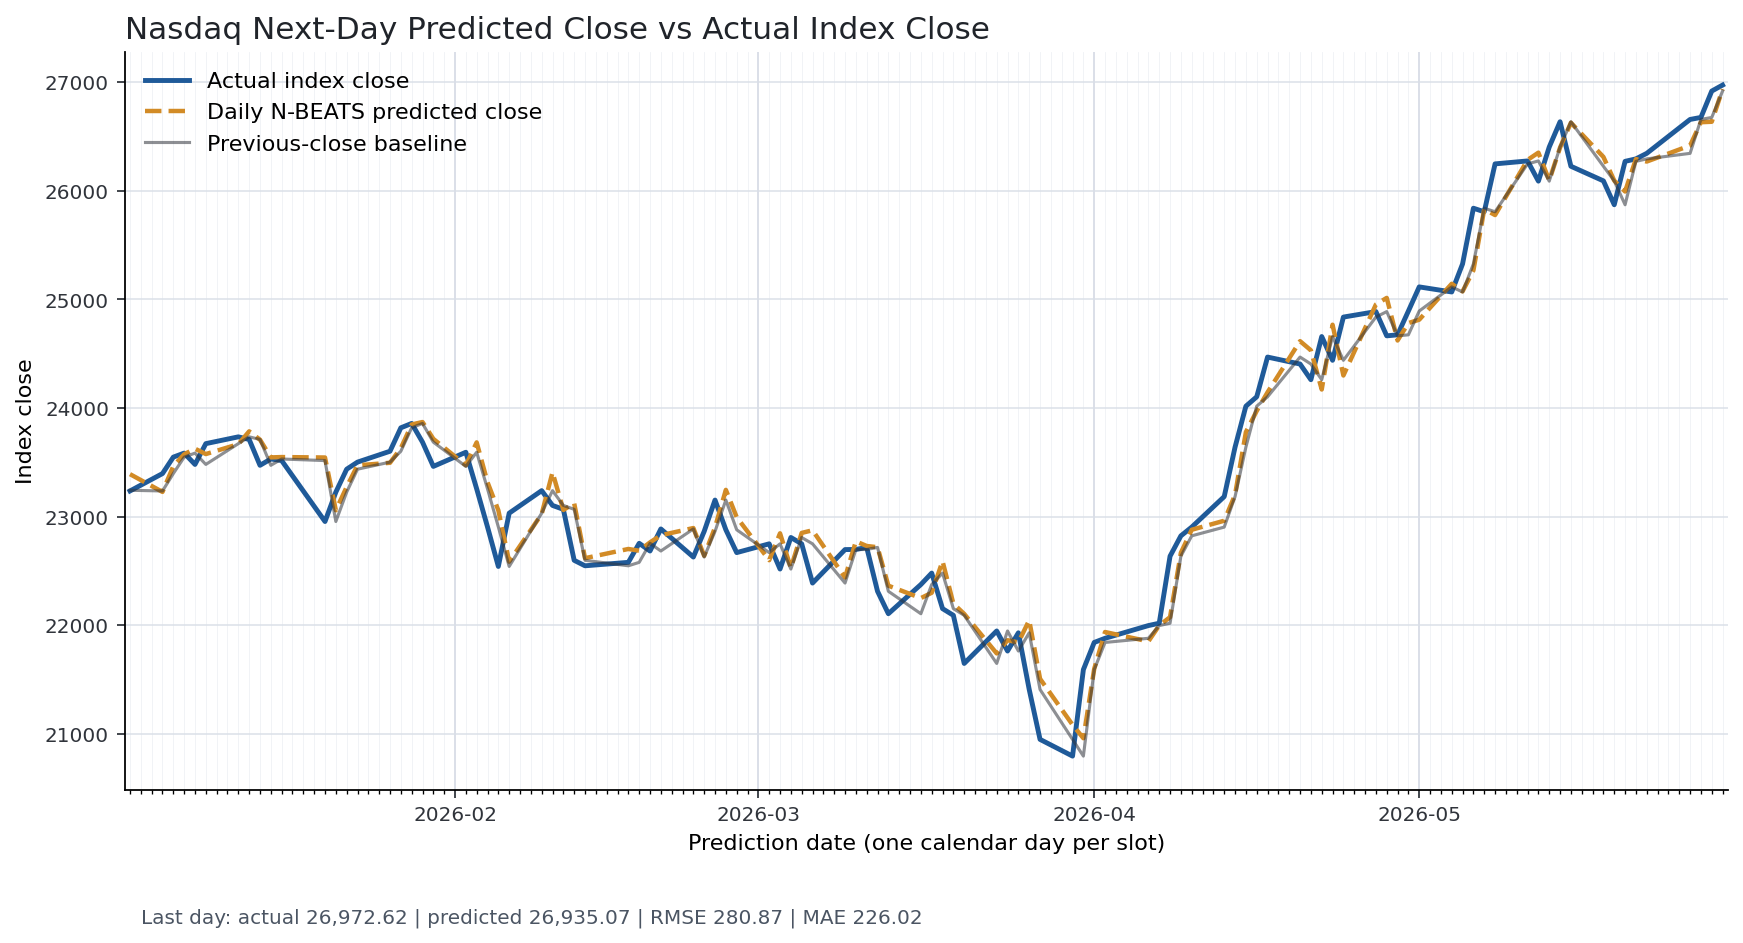

In [8]:
example_plot = PLOTS_DIR / "Nasdaq_price_prediction.png"
if example_plot.exists():
    display(Image(filename=str(example_plot)))
else:
    print(f"Plot not found: {example_plot}")
